# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_pM_fold,max_pE_fold,T_pM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
6,0.0,0.01,10000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
119,0.0,0.01,10000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
232,0.0,0.01,10000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
345,0.0,0.01,10000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
458,0.0,0.01,10000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35100069,0.1,0.01,10000000.0,1000000.0,10000000.0,948.683298,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302715e+06,75.662362,0.342872,0.694894,0.000000,0.0,20.0,1.013196,-0.98,0.243471,1.122876,0.000214,6.028348e+06,6.698971,2.651379,0.000021,0.000038
35100182,0.1,0.01,10000000.0,1000000.0,10000000.0,948.683298,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302673e+06,106.372656,0.443832,0.694367,0.000000,0.0,20.0,1.495475,0.00,0.243468,1.122870,0.000290,6.028388e+06,6.698971,2.651379,0.000042,0.000053
35100295,0.1,0.01,10000000.0,1000000.0,10000000.0,948.683298,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.302330e+06,489.309665,0.980774,0.738140,0.193271,0.0,20.0,4.720032,-0.89,0.243446,1.122822,0.001741,6.028720e+06,6.698971,2.651379,0.000213,0.000245
35100408,0.1,0.01,10000000.0,1000000.0,10000000.0,948.683298,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.288923e+06,8238.891834,2.794983,2.735117,8.486733,0.0,20.0,8.437405,-5.31,0.242564,1.120779,0.056215,6.041507e+06,6.698971,2.651379,0.006917,0.004119


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

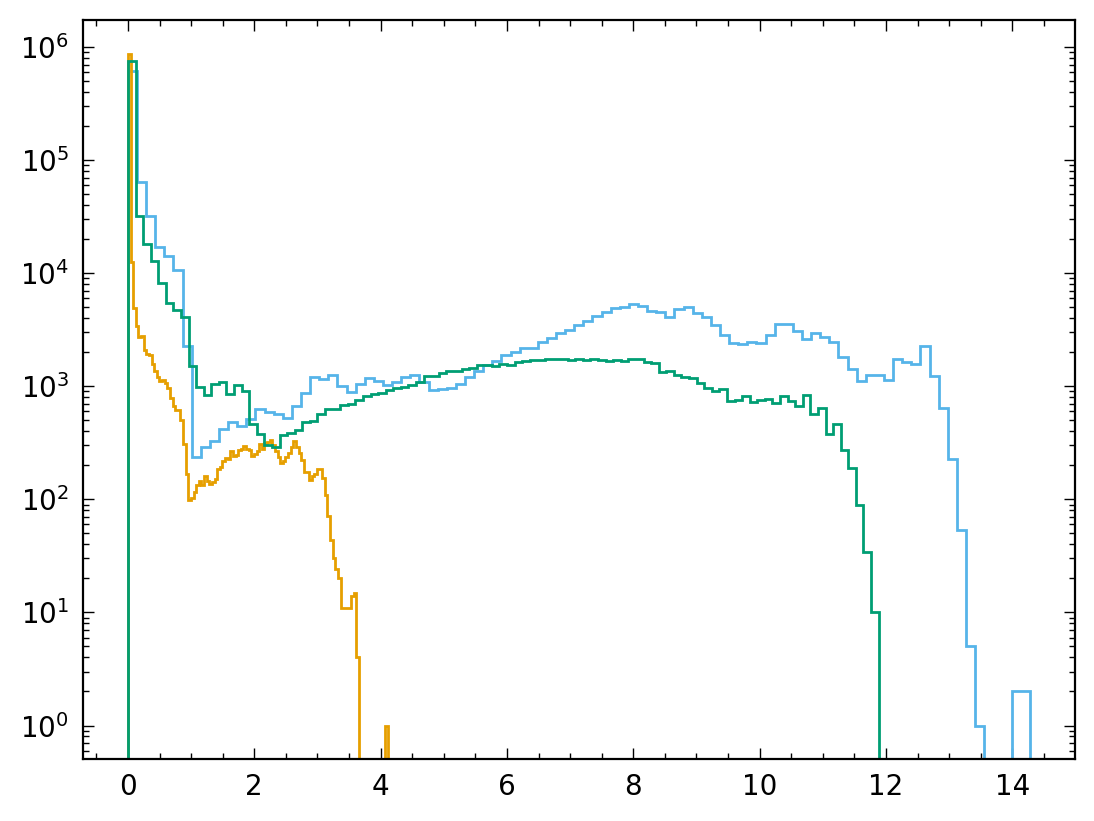

In [4]:
# Inspect distribution of observables
sel = 'peff_protection'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-6.698971,3.205826,1.043513,0.791618
1,0.700124,0.213863,1.188207,0.058724
2,0.717337,0.284544,1.371517,0.097591
3,0.735609,0.352728,1.497191,0.134626
4,0.755201,0.420099,1.584585,0.172537
...,...,...,...,...
98,2.569374,4.537636,1.632763,0.546075
99,2.677607,4.805343,1.659988,0.576142
100,2.813581,5.099120,1.660383,0.599527
101,6.698971,0.241162,1.116970,0.085248


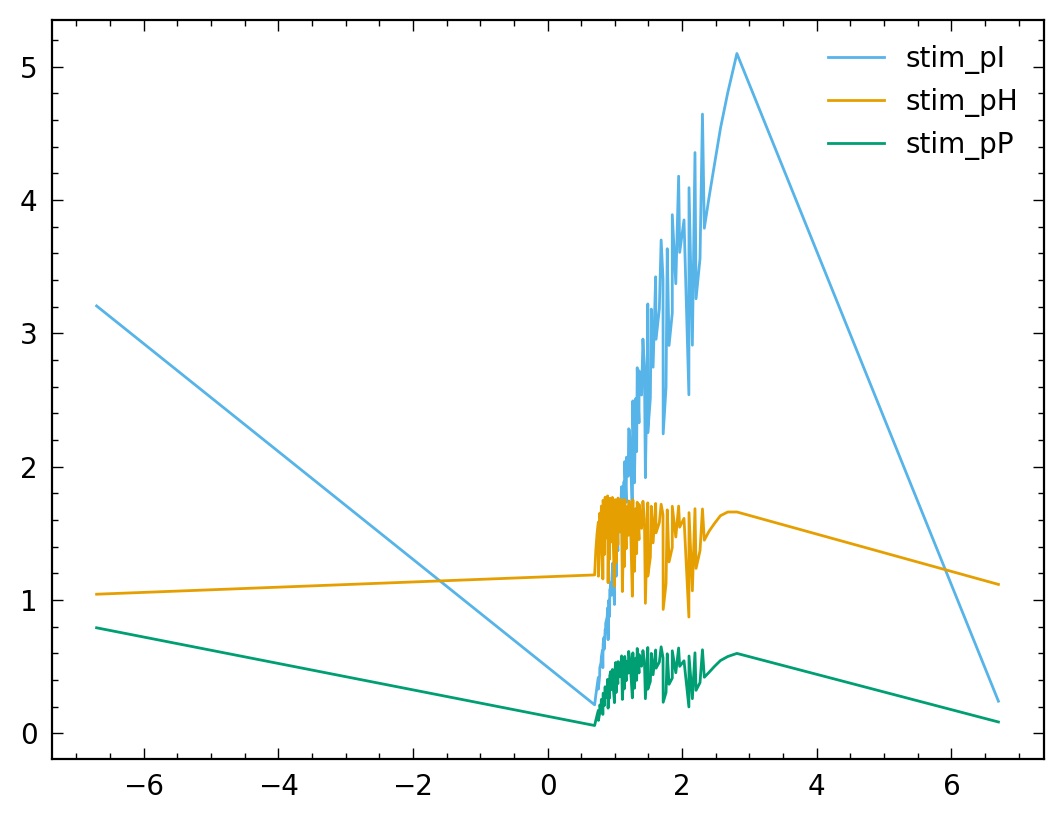

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 9
fevals: 12
fevals: 14
fevals: 13


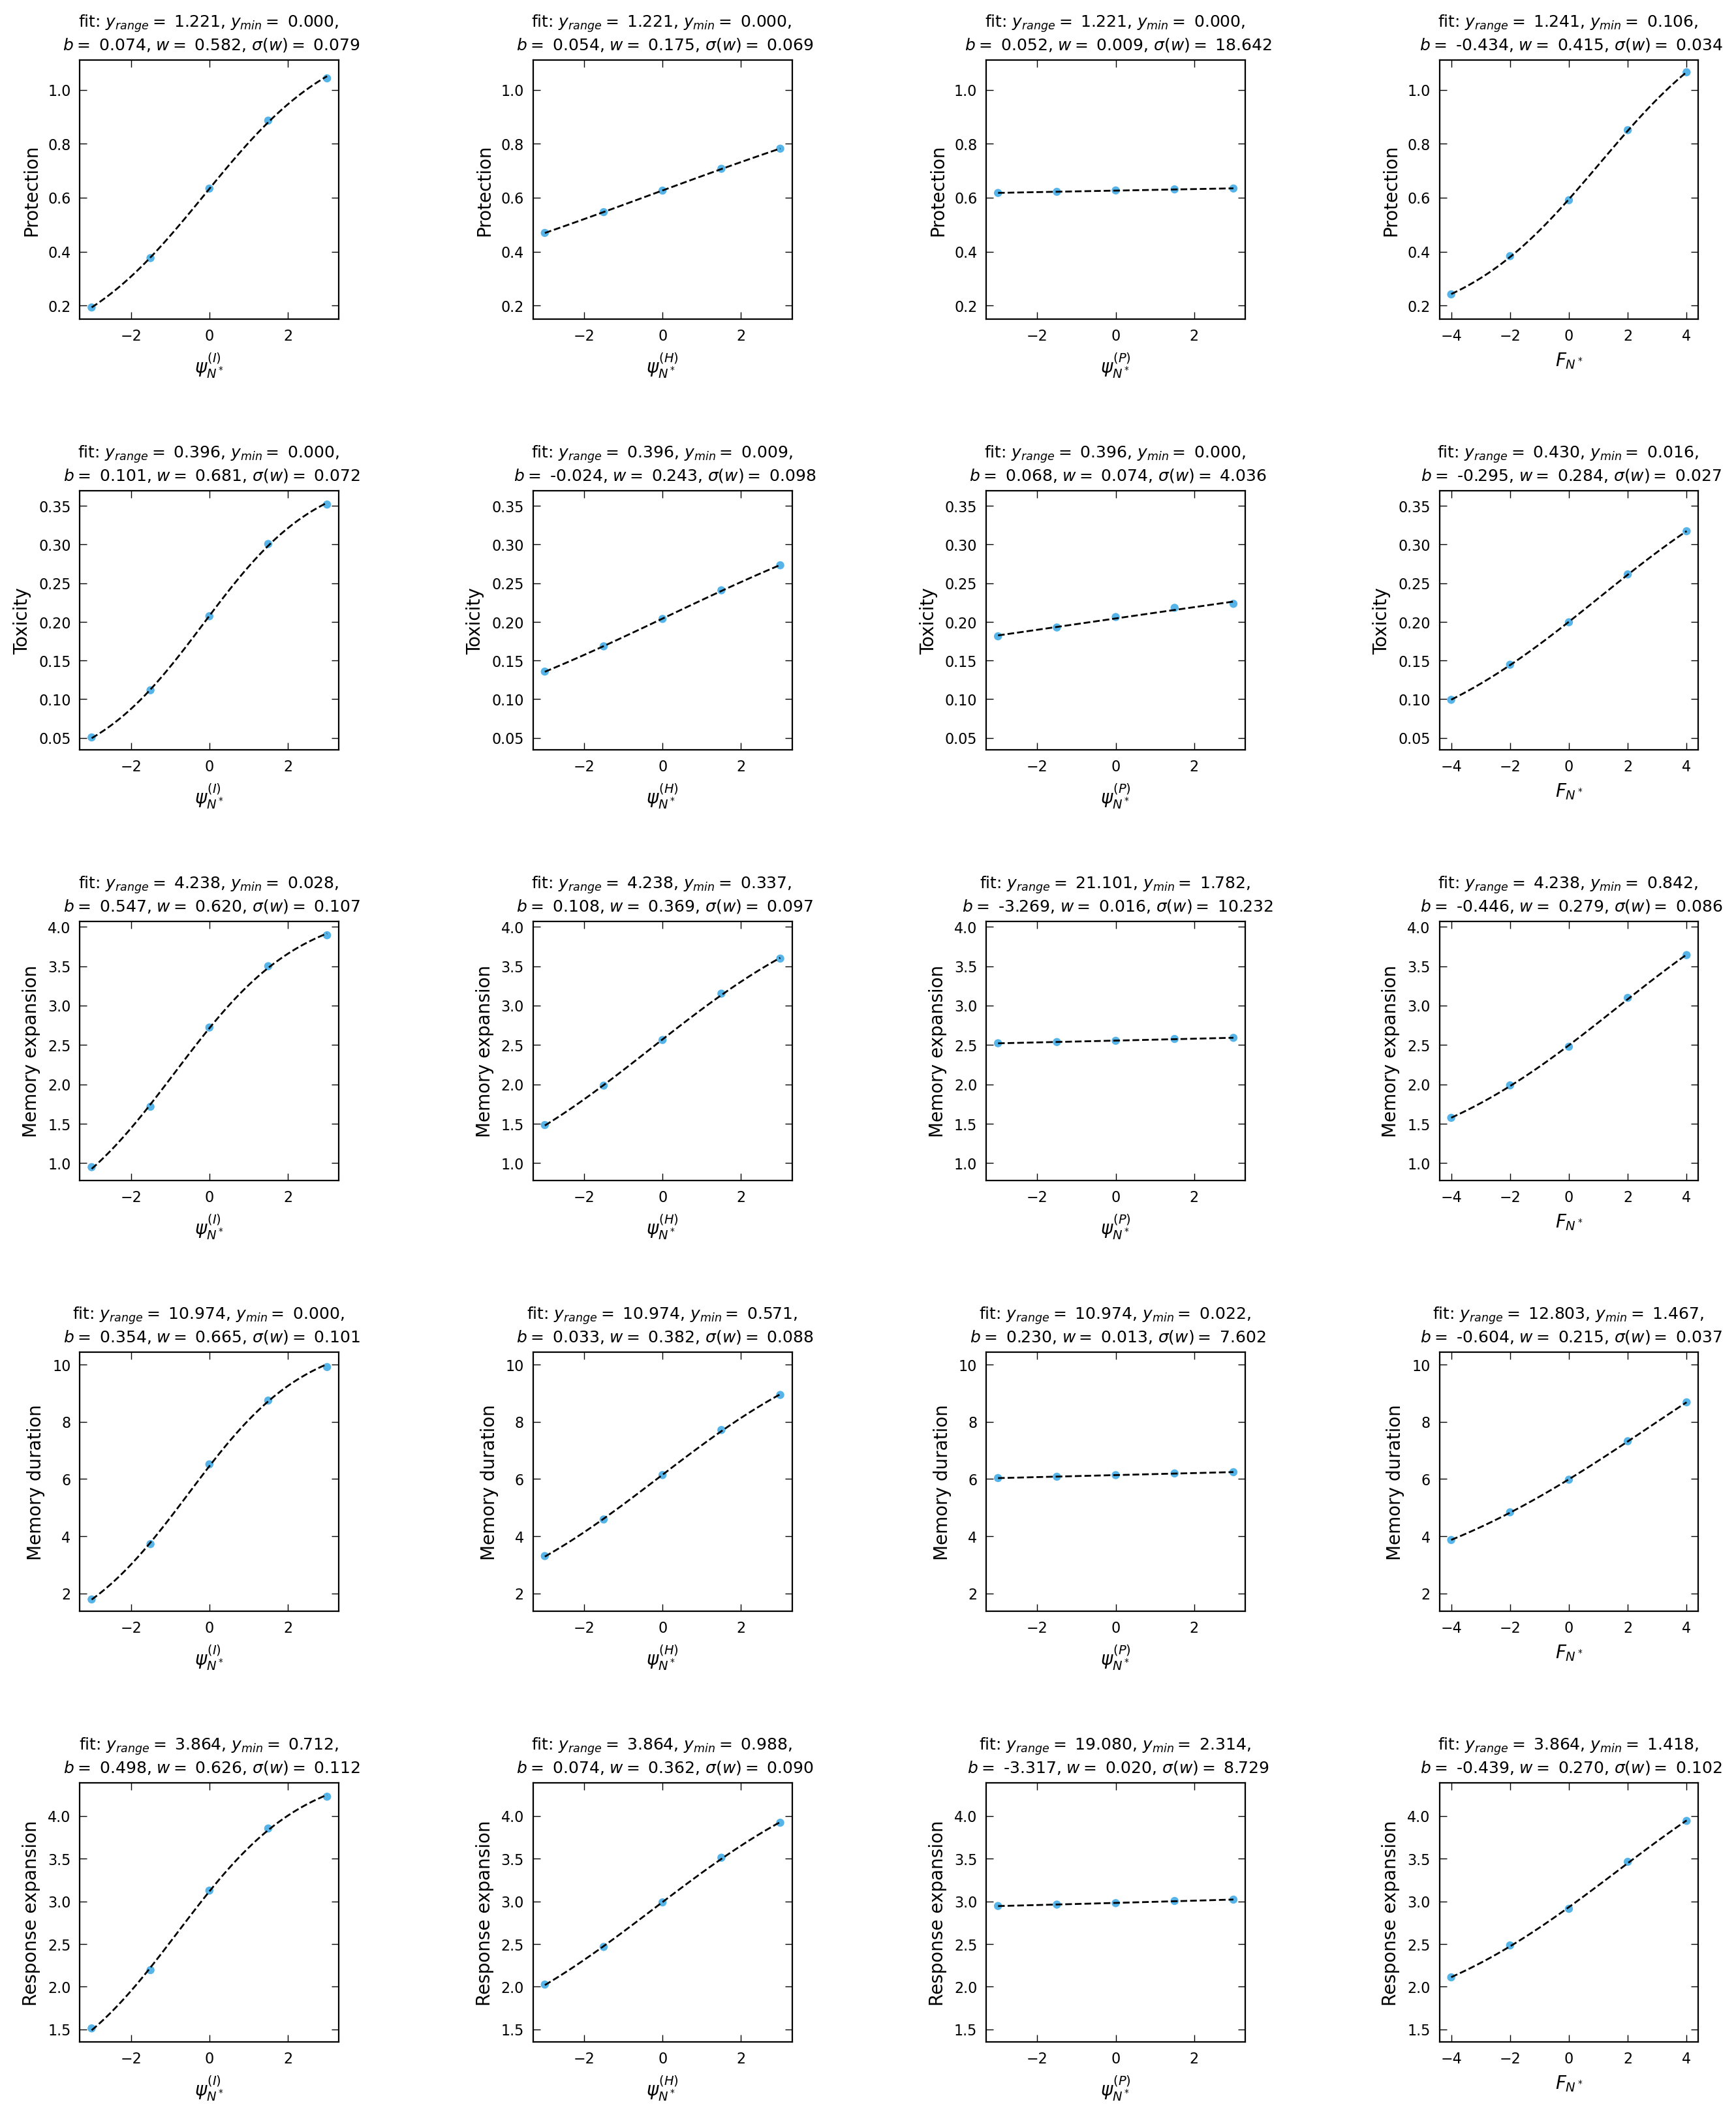

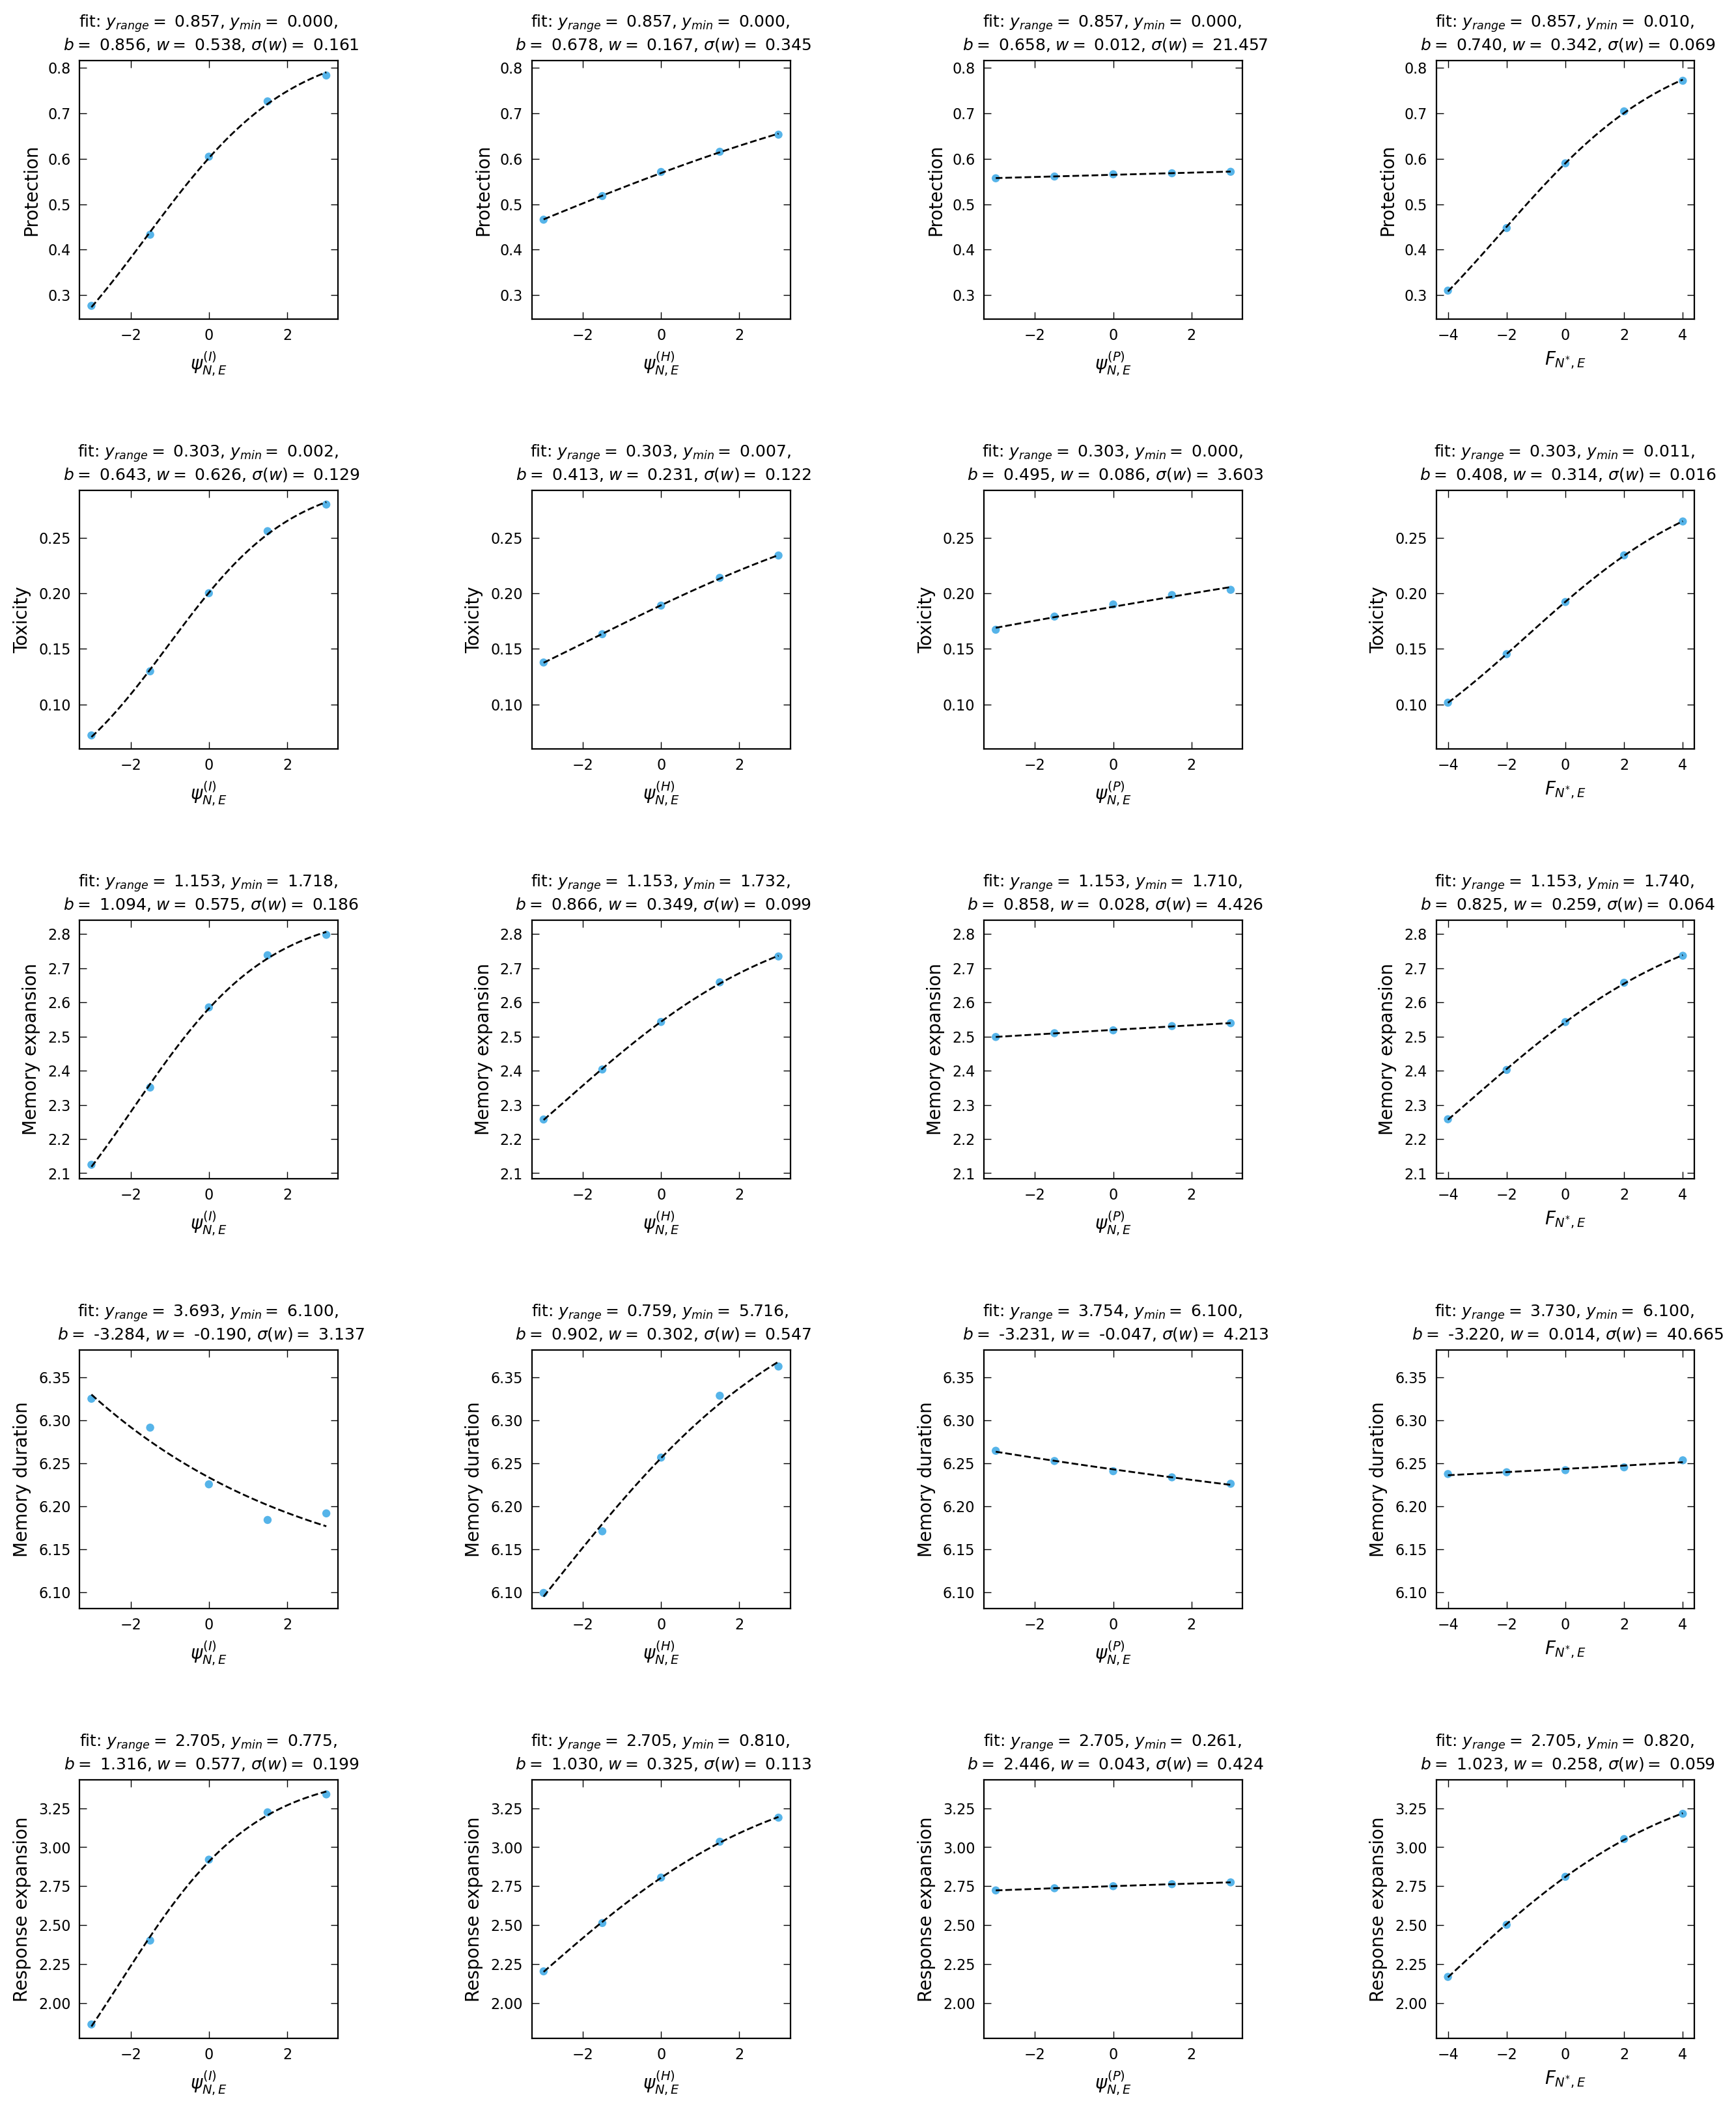

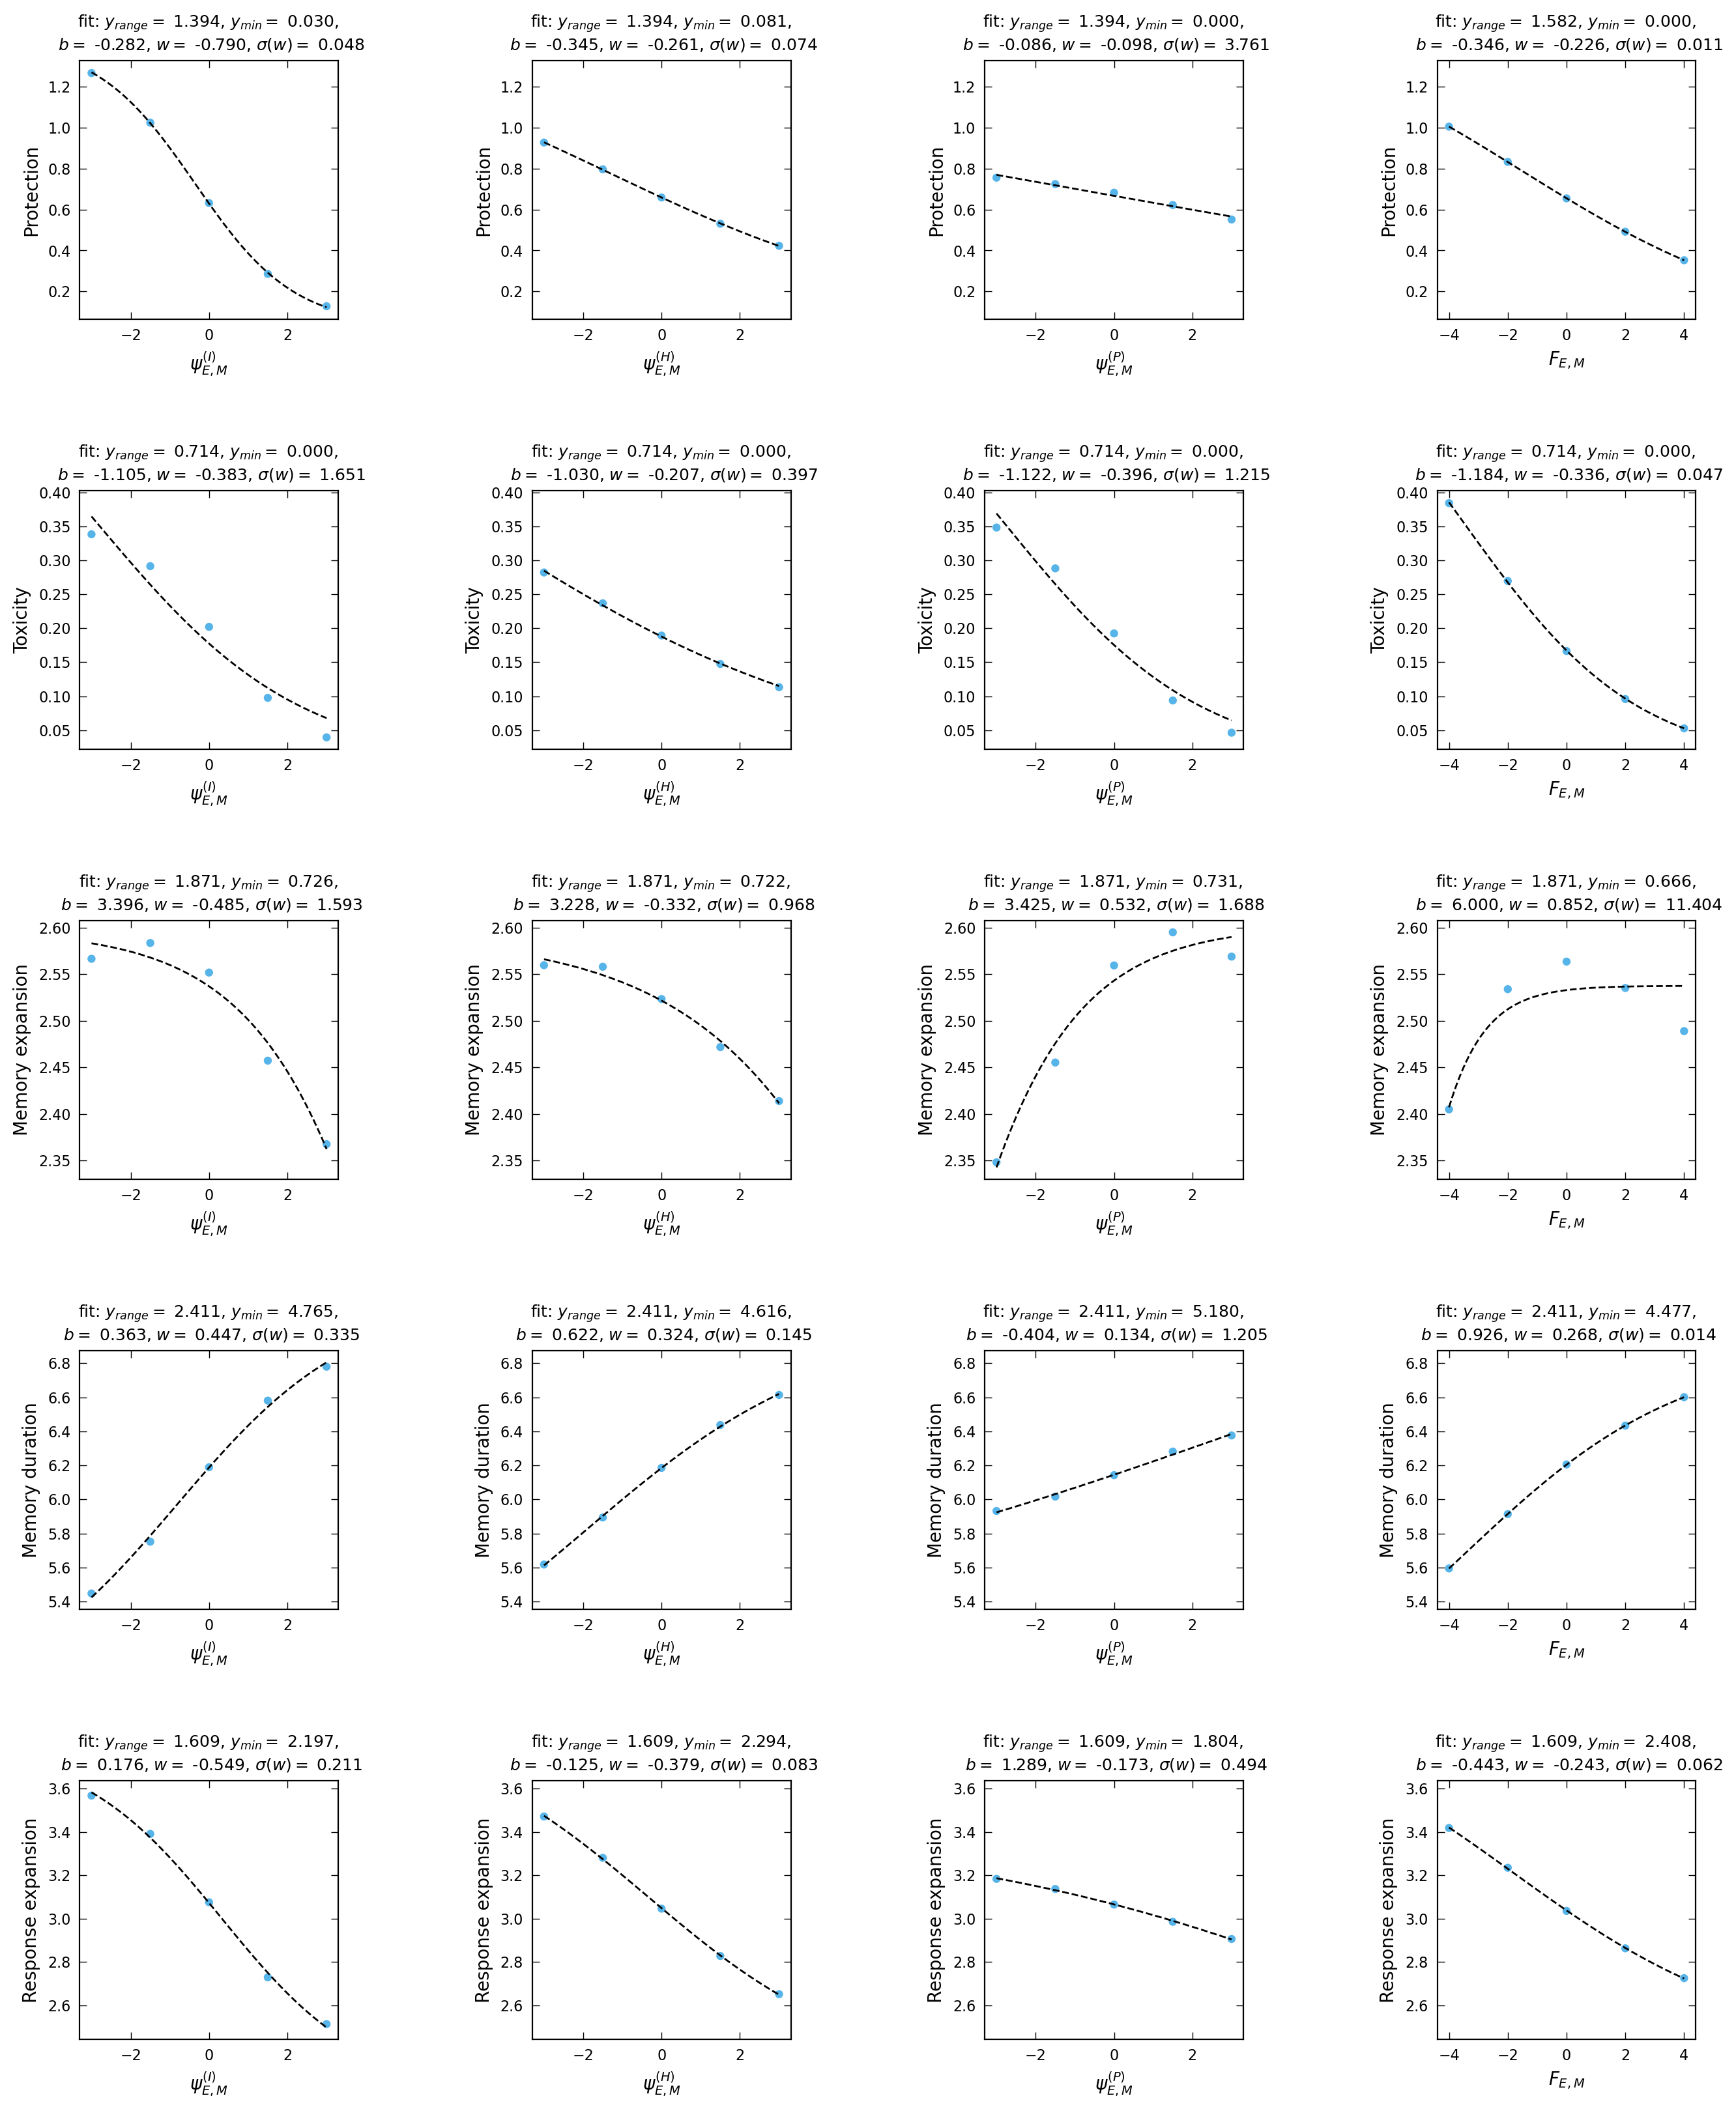

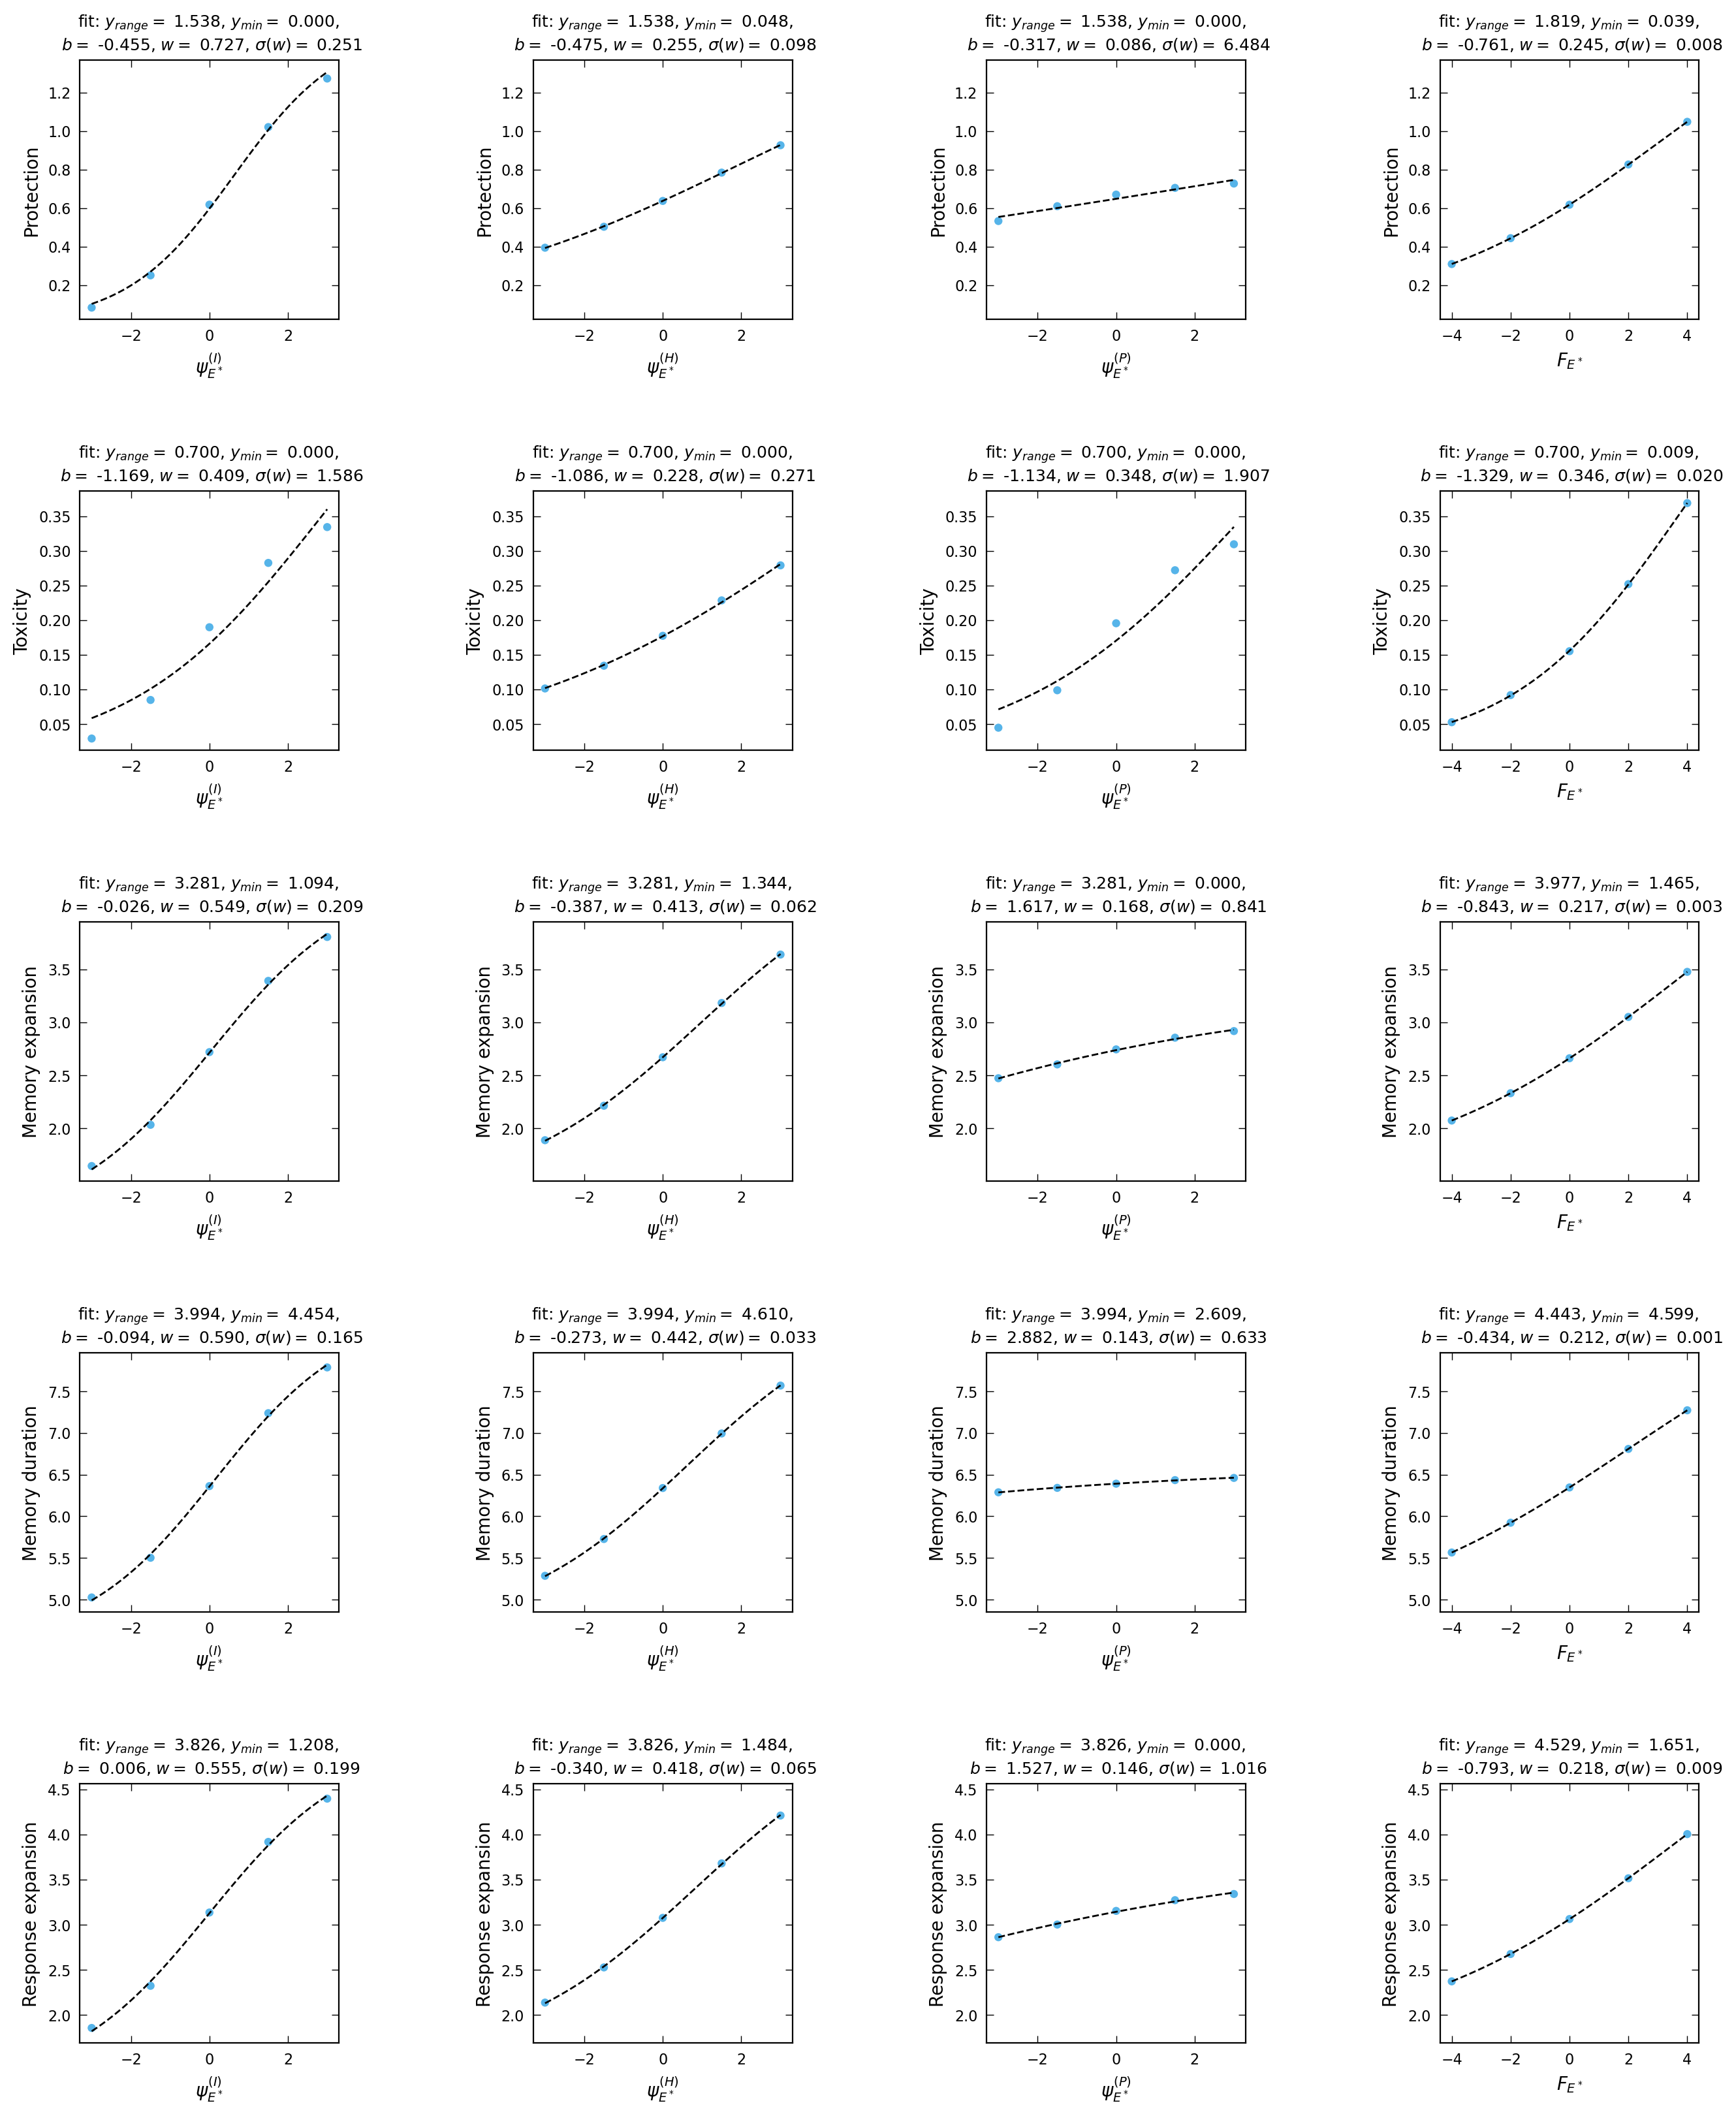

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 108
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0 if y_min > 0.0 else y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_min, 0.0] + len(variables)*[-2.5*F0_max] + num_modules*[-3.0*F0_max], 
                                     [2.0*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[2.5*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# View result
perf = 0 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
0,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,10000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.687654,0.060883,0.292531,NaN
5,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.180540,0.060883,0.003880,NaN
10,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.05,10000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.665597,0.267120,0.324858,NaN
15,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.05,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.173276,0.267120,0.006105,NaN
20,2.144660e+01,3.854503e-34,1.695145,0.081628,0.002903,1.260636,1.276592,0.065721,0.022093,0.827880,-6.914233,-0.974470,-0.860856,-2.233621,4.994956,0.728619,0.636453,1.656905,0.137858,1.580548,-3.076438,-1.945589,0.017463,0.001624,0.005049,0.002190,0.002179,0.003465,0.003999,0.002384,0.002378,0.002022,0.022609,0.005114,0.004931,0.006523,0.012073,0.003813,0.003741,0.003351,0.002675,0.005354,0.011981,0.005038,0.25,10000.0,1.500000e-07,50000.0,300.000000,10000000.0,1000.0,1.066261,21.446598,0.0,0.001645,0.0,0.804031,3.501721,5.383736,5.099120,1.660383,0.599527,2.813581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.024640e+01,3.740505e-11,1.199698,1.015904,0.054546,1.360710,0.676378,0.593315,0.042524,0.777574,-2.021735,-1.855121,-0.984657,-2.233904,2.601981,2.352510,1.302587,2.880298,0.508246,2.588910,-2.058590,-4.307859,0.007075

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

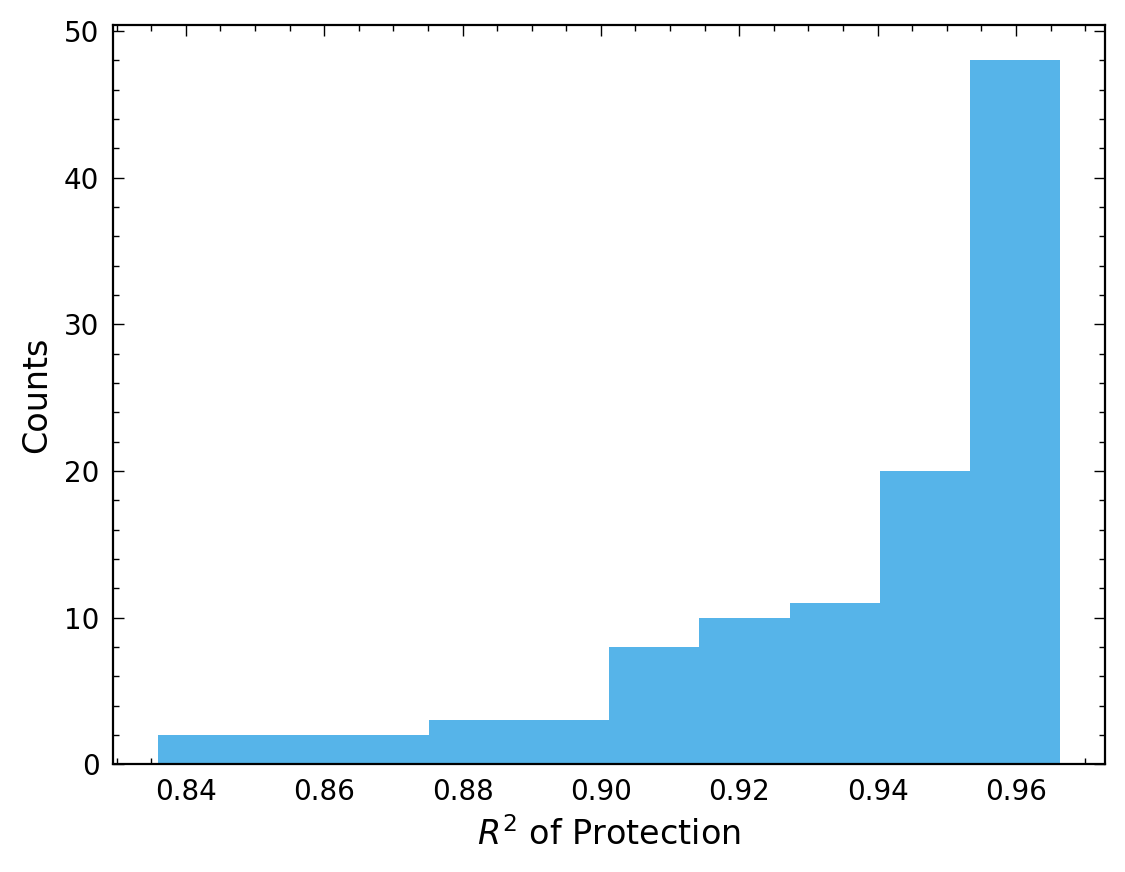

In [11]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

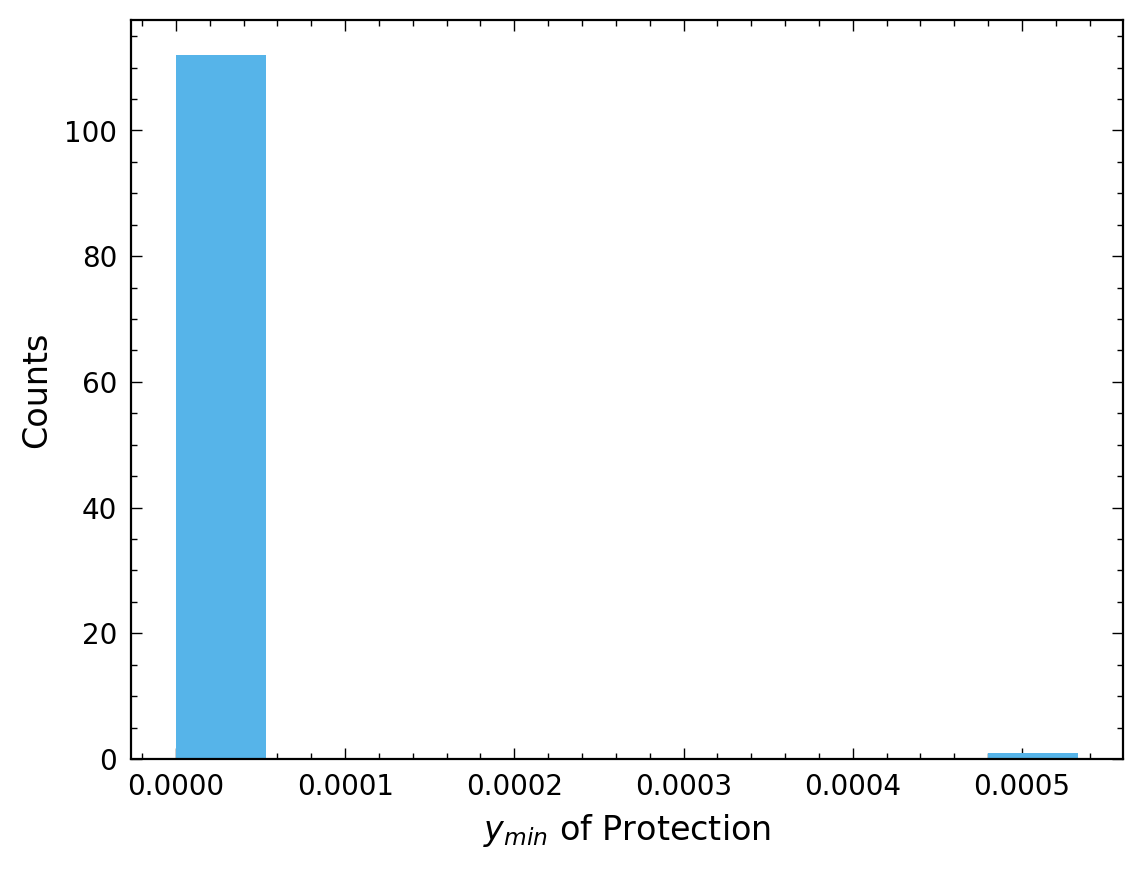

In [12]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

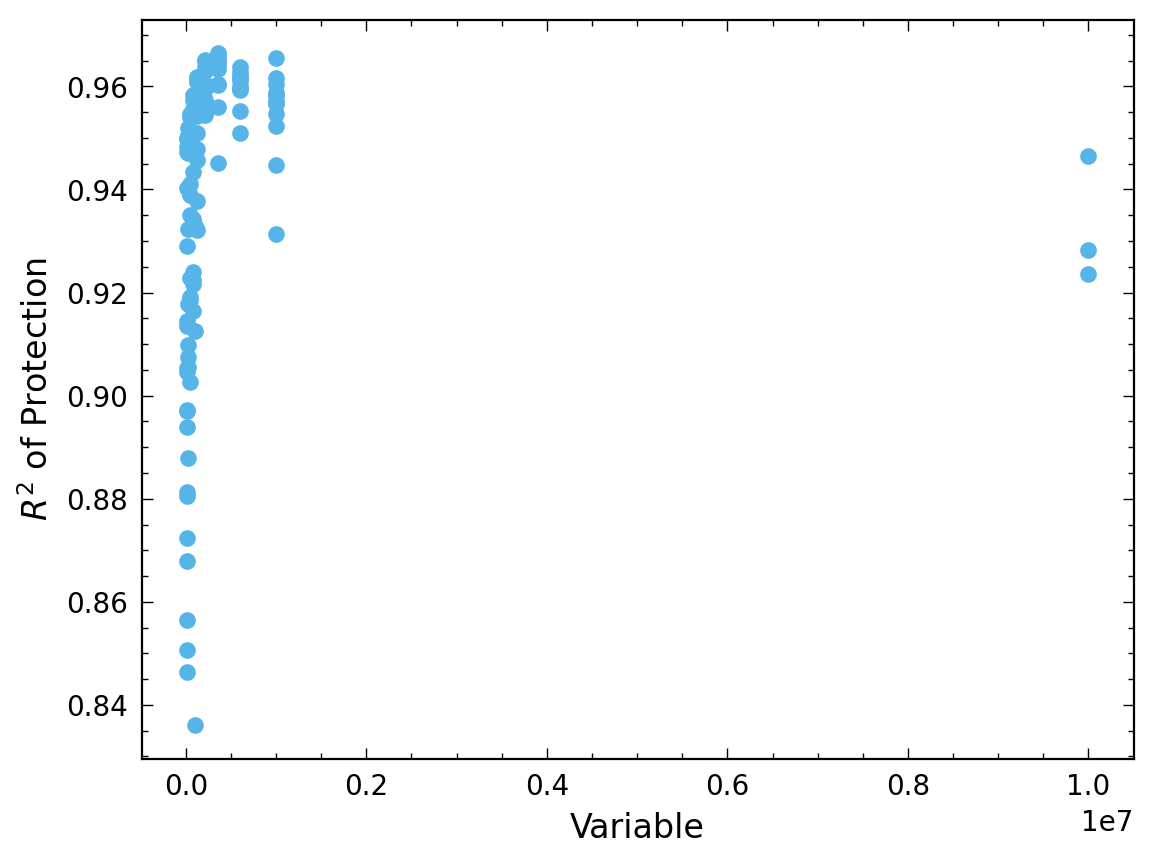

In [13]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].K_IE, model_r_sq);
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

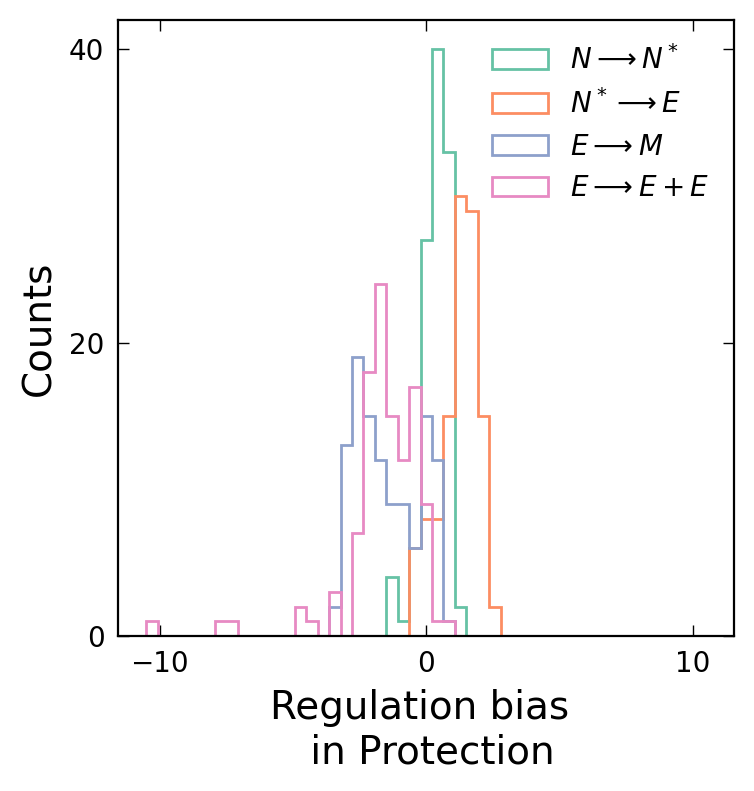

In [14]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

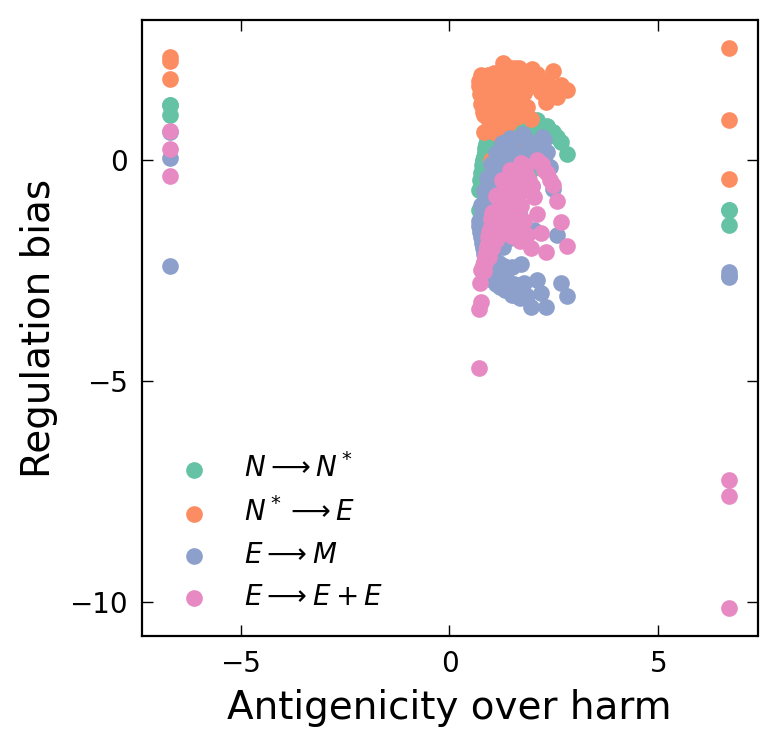

In [15]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

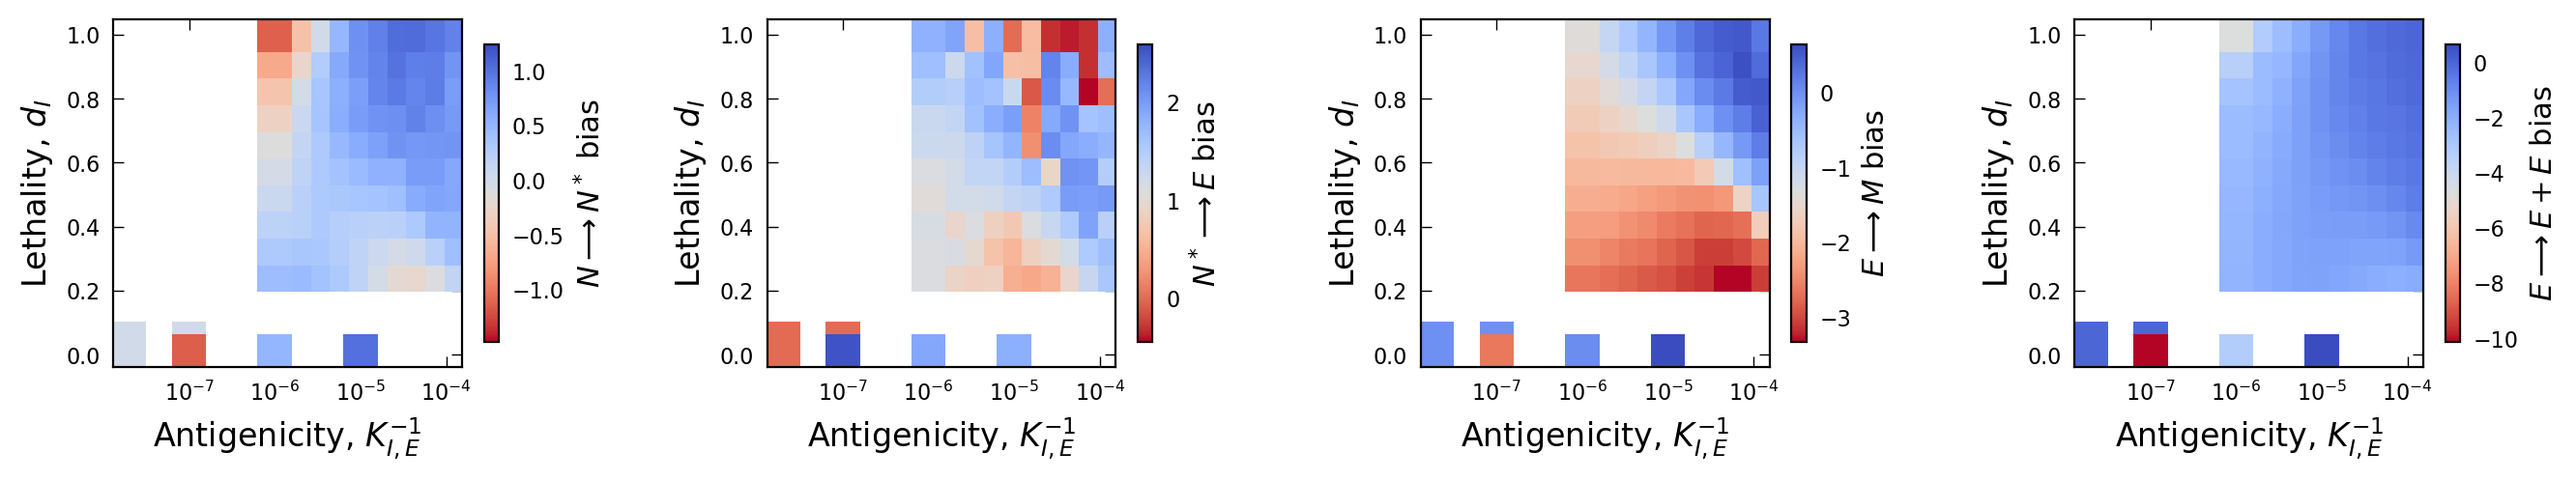

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

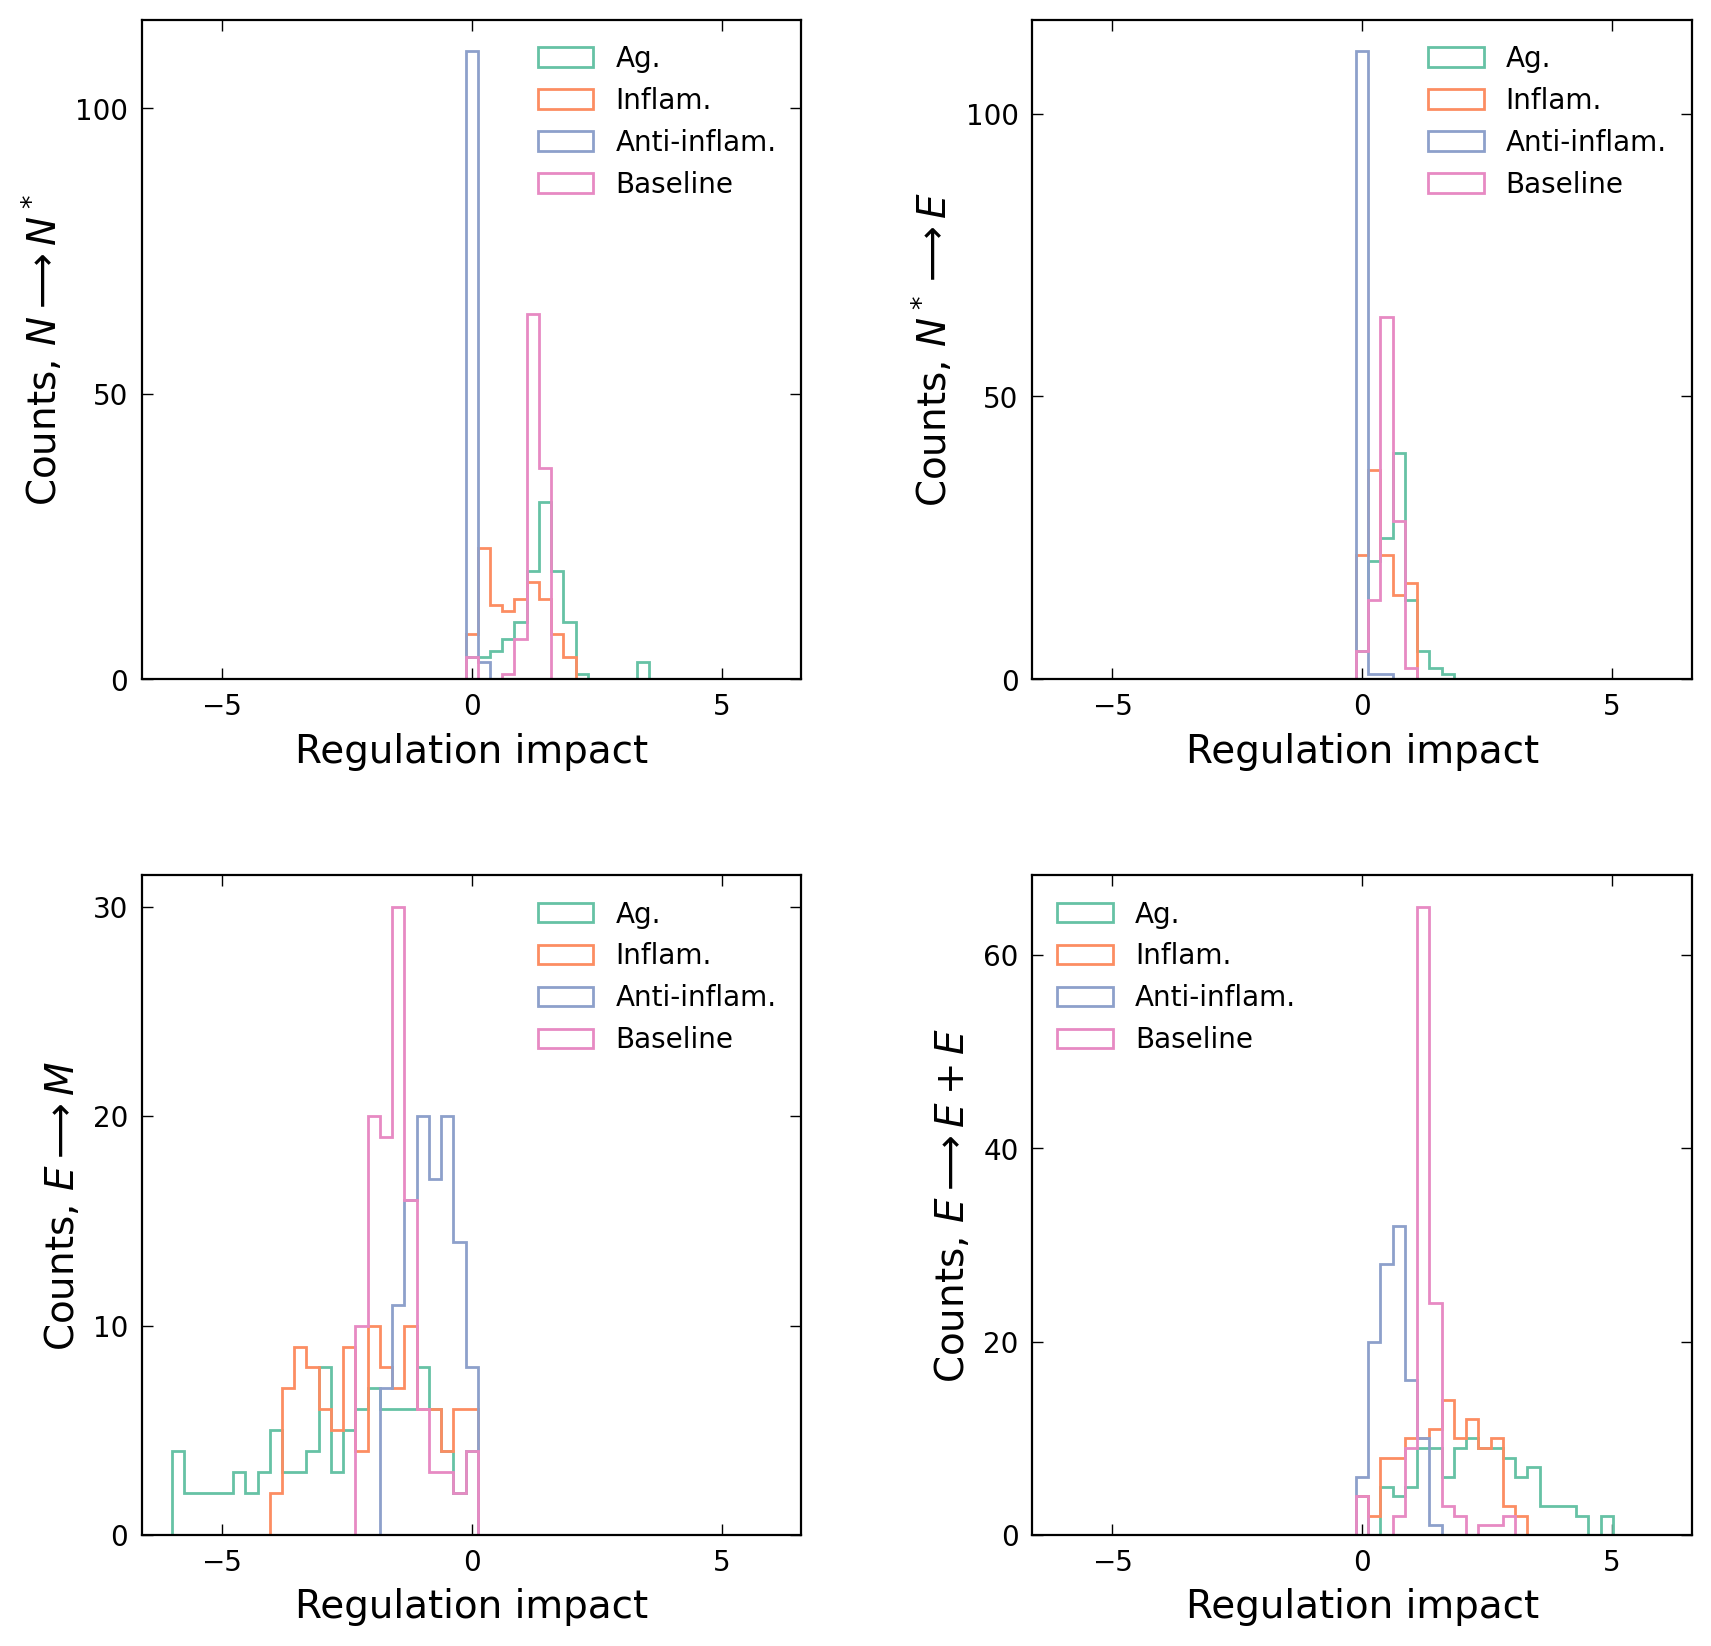

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-2.0*psi_max, 2.0*psi_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [18]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
0,4.940656e-324,4.940656e-324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,10000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.687654,0.060883,0.292531,NaN
5,4.940656e-324,4.940656e-324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.180540,0.060883,0.003880,NaN
10,4.940656e-324,4.940656e-324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.05,10000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.665597,0.267120,0.324858,NaN
15,4.940656e-324,4.940656e-324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.173276,0.267120,0.006105,NaN


In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
520,10.743591,3.464609e-13,3.532172,0.968613,0.035434,1.363466,1.632395,0.456670,0.013748,0.571539,-5.966164,-1.772372,-0.768488,-2.189886,4.086057,1.229210,0.588164,1.514159,1.239225,2.247085,-2.407130,-0.365781,0.010403,0.001293,0.010915,0.004986,0.003846,0.003523,0.006806,0.003560,0.003066,0.002445,0.017483,0.006510,0.004663,0.005820,0.016456,0.006250,0.004368,0.005805,0.005168,0.009616,0.008351,0.003046,0.01,100000.0,0.1,50000.0,94.868330,10000000.0,1000000.0,0.910041,10.743591,0.0,0.010454,0.0,0.614919,2.372730,2.651379,3.254684,1.074374,0.468168,-6.698971
525,12.002188,2.782781e-16,3.547230,0.968269,0.045583,1.371299,1.576097,0.442577,0.020197,0.593641,-4.213543,-1.254930,-0.711554,-1.590393,4.492548,1.361092,0.731107,1.699081,1.243107,2.333777,0.046715,0.239471,0.012624,0.002039,0.012521,0.005639,0.004325,0.004098,0.007508,0.003949,0.003425,0.002887,0.021417,0.007792,0.005641,0.007850,0.023944,0.008680,0.005986,0.008854,0.005945,0.011318,0.003618,0.003759,0.01,100000.0,0.1,50000.0,300.000000,10000000.0,1000000.0,1.386530,11.831667,0.0,0.033823,0.0,0.905863,3.063347,2.651379,3.198677,1.046242,0.760383,-6.698971
530,17.724397,1.639586e-14,3.351983,0.914711,0.071434,1.301009,1.437697,0.387210,0.031767,0.562988,-1.162695,-0.339639,-0.221119,-0.475457,1.854445,0.549447,0.337581,0.701454,1.017391,1.832039,0.642924,0.656312,0.038024,0.004810,0.016059,0.007130,0.005473,0.005329,0.008387,0.004586,0.004085,0.003087,0.005981,0.003446,0.003207,0.001975,0.009044,0.004665,0.004164,0.002707,0.006902,0.011497,0.006562,0.005945,0.01,100000.0,0.1,50000.0,948.683298,10000000.0,1000000.0,2.497463,14.275846,0.0,0.108666,0.0,1.663707,4.108556,2.651379,3.164117,1.009924,1.146303,-6.698971
535,11.277683,2.662483e-40,0.701231,0.610048,0.040521,0.788653,0.781047,0.685670,0.064743,0.924285,-1.888333,-1.713159,-0.910333,-2.070288,2.441429,2.240721,1.167355,2.776303,-0.248389,2.044794,-2.925287,-4.800534,0.012179,0.000786,0.002423,0.002284,0.001780,0.001863,0.003517,0.003349,0.002682,0.002686,0.006104,0.005673,0.003839,0.005780,0.012372,0.011365,0.006531,0.013362,0.002791,0.007331,0.010130,0.025949,0.01,1000000.0,0.1,50000.0,94.868330,10000000.0,1000000.0,0.430302,11.277683,0.0,0.001612,0.0,0.395745,1.511195,2.651379,1.290905,1.099634,0.233501,inf
540,10.246397,3.740505e-11,1.199698,1.015904,0.054546,1.360710,0.676378,0.593315,0.042524,0.777574,-2.021735,-1.855121,-0.984657,-2.233904,2.601981,2.352510,1.302587,2.880298,0.508246,2.588910,-2.058590,-4.307859,0.007075,0.000786,0.003349,0.003041,0.002034,0.003078,0.002825,0.002694,0.002190,0.002136,0.004892,0.004596,0.003165,0.004752,0.008682,0.007919,0.004898,0.008906,0.002732,0.007752,0.004733,0.016398,0.01,1000000.0,0.1,50000.0,300.000000,10000000.0,1000000.0,0.644284,10.246397,0.0,0.005387,0.0,0.392656,1.974294,2.651379,1.265136,1.080081,0.353065,inf
545,12.666264,1.186200e-13,1.174945,0.988290,0.068090,1.356272,0.477104,0.410265,0.036541,0.557796,-1.297749,-1.185316,-0.748677,-1.475512,2.166646,1.964164,1.149510,2.453355,0.500007,1.907325,0.035118,-3.228120,0.012125,0.001281,0.003881,0.003513,0.002377,0.003614,0.002629,0.002515,0.002147,0.002000,0.004842,0.004531,0.003433,0.004819,0.006829,0.006330,0.004348,0.006870,0.003193,0.007721,0.002785,0.011555,0.01,1000000.0,0.1,50000.0,948.683298,10000000.0,1000000.0,0.982805,11.88